#### Oliver Mann - 2521889
## Coursework Assesment Question 3: Agent-based Modelling

Model template is given

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from mesa import model
from mesa.batchrunner import batch_run
from question3_supplement.Opinion.OpinionModel import OpinionWorld

rng = np.random.default_rng(42)

### Q 3A
The population opinion does not converge as expexcted. It could be argued that over time through discussion and debate, agents will come to a comprimise, shown by the graph of agent opinions below, converging to a neutral opinion around 0. 

In a real-world case, it is more likely that agents with more extreme views close to either $x_i = 1$ or $x_i = -1$ are less likely to be persuaded to change their view or listen to other opposing views. The model does differs in this sense as the default confidnece level is set to 2, meaning all agents are able to influence any other agent's opinion at any time.

Therefore, the model behaves as expected with the default parameter values but with more realistic values (such as a lower confidence level), the model may produce more realistic results.

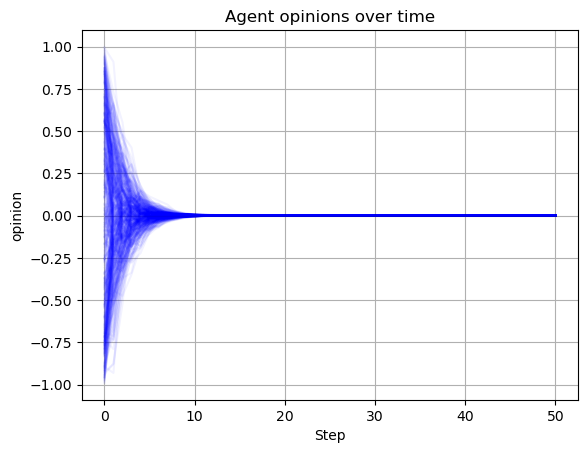

In [2]:
model = OpinionWorld(seed=42)

# 50 steps of model
for i in range(50):
    model.step()

# collect data
model_df = model.datacollector.get_agent_vars_dataframe().reset_index()

# plot
g = sns.lineplot(data=model_df, x='Step', y='opinion', units='AgentID', color = 'blue', alpha=0.05, estimator=None)
plt.title('Agent opinions over time')
plt.grid()

### Q 3bi

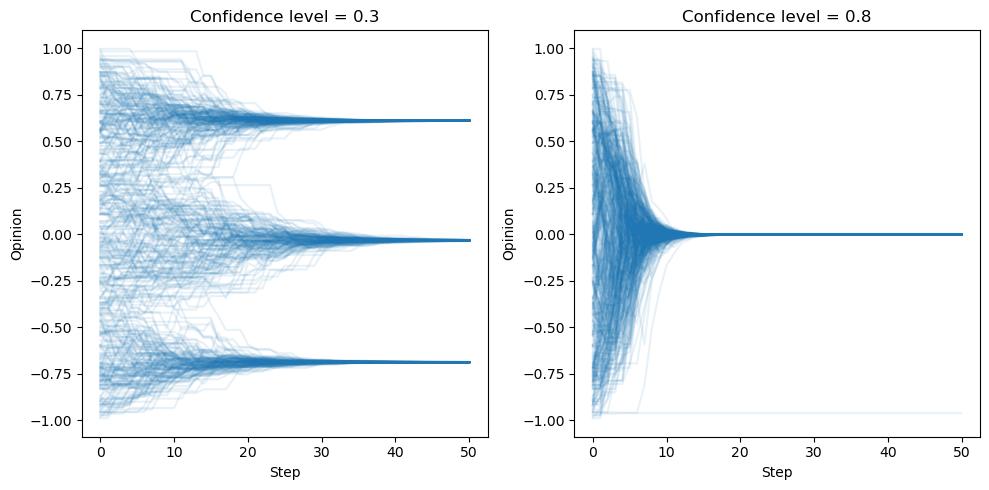

In [3]:
# Q 3B(i)

def run_model(d, steps=50, seed=42):
    model = OpinionWorld(seed=seed, confidence_threshold=d)
    for i in range(steps):
        model.step()
    return model

# run models for different confidence levels
reserved = 0.3
confident = 0.8
d_reserved = run_model(reserved)
d_confident = run_model(confident)

# collect data
d_reserved_df = d_reserved.datacollector.get_agent_vars_dataframe()
d_confident_df = d_confident.datacollector.get_agent_vars_dataframe()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(data=d_reserved_df, x="Step", y="opinion", units='AgentID', alpha=0.1, estimator=None, ax=ax1)
sns.lineplot(data=d_confident_df,  x="Step", y="opinion", units='AgentID', alpha=0.1, estimator=None, ax=ax2)

ax1.set_xlabel('Step')
ax2.set_xlabel('Step')
ax1.set_ylabel('Opinion')
ax2.set_ylabel('Opinion')
ax1.set_title(f'Confidence level = {reserved}')
ax2.set_title(f'Confidence level = {confident}')
plt.tight_layout()
plt.show()



The graphs above show that opinion does not always reach a consnsus. For lower confidence levels, cliques form with the same opinion. On the other hand, for higher confidence levels, a more neutral opinion is reached because agents will listen to other agents with more differing views.

### Q 3Bii

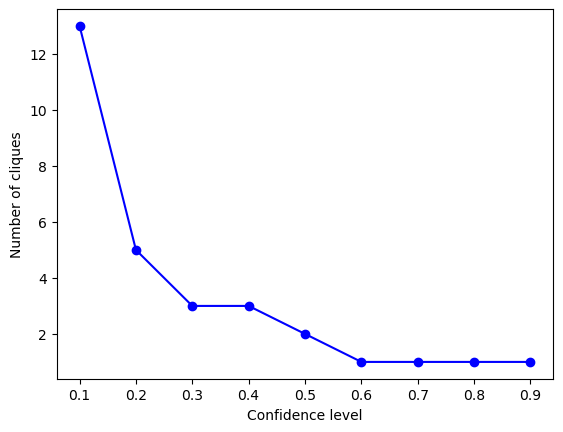

In [4]:
# Q 3B(ii)

# using the function from the assesment question sheet
def ret_num_cliques(opinions, confidence_threshold):
    # begin with one clique
    num_cliques = 1

    # sort opinions in increasing order, ignoring outliers
    sorted_constrained_opinions = sorted([opinion for opinion in opinions if abs(
        opinion)<= (1 - (0.5 * confidence_threshold))])
    
    # set the minimum opinion value
    x_min = sorted_constrained_opinions[0]
    
    for opinion in sorted_constrained_opinions:
    # check if there are any opinions outside of the current range of influence, 
    # i.e. different clique
        if opinion > (x_min + confidence_threshold):
        # if yes, update minimum opinion value and number of cliques
            x_min = opinion
            num_cliques += 1
    return num_cliques


confidence_levels = np.arange(0.1, 1, 0.1).tolist()

cliques = []
for confidence in confidence_levels:
    model = run_model(confidence)
    opinions = [agent.opinion for agent in model.agents]
    cliques.append(ret_num_cliques(opinions, confidence))


fig, ax = plt.subplots()
ax.plot(confidence_levels, cliques, 'o-', color='blue')
ax.set_xlabel('Confidence level')
ax.set_ylabel('Number of cliques')
plt.show()

The graph shows that the number of cliques is highest for low confidence levels. This is because when the confidence level is low, agents ony interact with others with similar opinions. When confidence level is higher, agents are influenced by a wider range of opinions, causing cliques to merge together.

### Q 3Ci

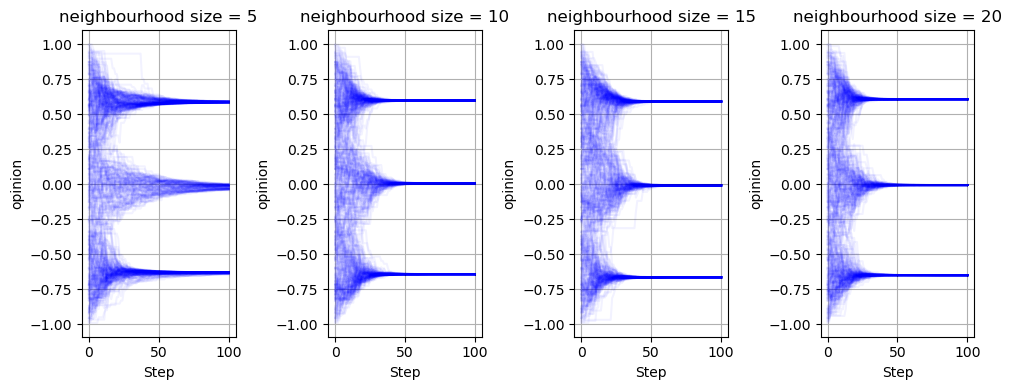

In [5]:
def run_model(n_size, d=0.3, steps=100, seed=42):
    model = OpinionWorld(neighbourhood_size=n_size, seed=seed, confidence_threshold=d)
    for i in range(steps):
        model.step()
    return model

# line plots from single runs
fig, ax = plt.subplots(1, 4, figsize=(10, 4))

for i, n_size in enumerate([5, 10, 15, 20]):
    model = run_model(n_size)
    model_df = model.datacollector.get_agent_vars_dataframe().reset_index()
    sns.lineplot(data=model_df, x='Step', y='opinion', units='AgentID', color = 'blue', alpha=0.05, estimator=None, ax=ax[i])
    ax[i].set_title(f'neighbourhood size = {n_size}')
    ax[i].grid()
plt.tight_layout()
plt.show()

  0%|          | 0/120 [00:00<?, ?it/s]

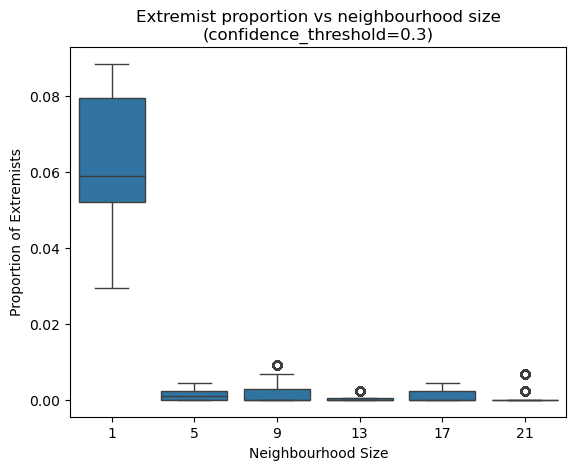

In [6]:
params = {
        'confidence_threshold': 0.3,
        'neighbourhood_size': list(range(1, 22, 4)),
        'seed': rng.integers(1, 100, 20)
        }

results = batch_run(
        OpinionWorld,
        parameters=params,
        max_steps=100,
        )

results_df = pd.DataFrame(results)

# filter for last step only
final_df = results_df.loc[(results_df['Step']==results_df['Step'].max())]

sns.boxplot(data=final_df, x='neighbourhood_size', y='proportion_of_extremists')
plt.xlabel('Neighbourhood Size')
plt.ylabel('Proportion of Extremists')
plt.title('Extremist proportion vs neighbourhood size\n(confidence_threshold=0.3)')
plt.show()


The proportion of extremists is highest when neighbourhood size is low, as agents only interact locally and extreme opinions are less likely to be influenced by other agents' opinions. As neighbourhood size increases, agents are exposed to a wider range of opinions, which quickly reduces extreme views and reuslts in agents converging to a more neutral consensus.

### Q 3Cii
The model uses an orthogonal Von Neumann neighbourhood, where agents are connected to 4 adjacent neighbours in a grid. This means that agents are limited to local interactions which creates clusters, particuarly for small neighbourhood sizes. This is evident in the boxplot as extreme views  remain at the final step when neighbourhood size is low because extreme agents haven't had the opportunity to interact with enough agents with more moderate views.

A network-based model would represent agents as nodes and social relationships as edges. Network distances could be measured by the strength of rapport or influence between agents. Students would have varying numbers of connections to represent different levels of sociability.

### Q 3D

It is unreasonable to assume people's initial opinions are distributed uniformly as this suggests that extreme views are just as common as moderate views. A bell shaped distribution (such as normal) may be more suited as it would result in fewer extreme views, fewer cliques and faster convergence.

Furthermore, it could be argued that representing someone's opinions on a 1D spectrum is unsuitable and limmiting. For example, political views are often mapped onto a 2D spectrum. However, opinions on cats are less complex than politcal views and in this case a 1D spectrum is resonable.

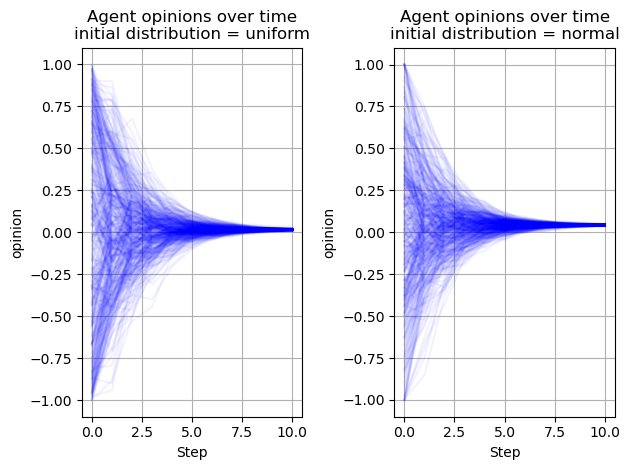

In [7]:
model_u = OpinionWorld(initialisation_type='uniform')
model_n = OpinionWorld(initialisation_type='normal')

# 50 steps of model
for i in range(10):
    model_u.step()
    model_n.step()

# collect data
model_u_df = model_u.datacollector.get_agent_vars_dataframe().reset_index()
model_n_df = model_n.datacollector.get_agent_vars_dataframe().reset_index()

# plot
fig, (ax1, ax2) = plt.subplots(1, 2)
sns.lineplot(data=model_u_df, x='Step', y='opinion', units='AgentID', color = 'blue', alpha=0.05, estimator=None, ax=ax1)
sns.lineplot(data=model_n_df, x='Step', y='opinion', units='AgentID', color = 'blue', alpha=0.05, estimator=None, ax=ax2)
ax1.set_title('Agent opinions over time\ninitial distribution = uniform')
ax2.set_title('Agent opinions over time\ninitial distribution = normal')
ax1.grid()
ax2.grid()
plt.tight_layout()

The normal distribution has a marginal effect on the convergence of opinion, with this happening slightly earlier than in the case of the uniform distrubution.

### Q 3E

Steps taken to add subborn behaviour:
1. Updated agents to have a stubborn property. If this is false, agents will be able to converse and update their opnions. Otherwise their opinions will remain unchanged.
2. Only a certain proportion of agents are stubborn. They must have a negative view on the SEMT cat to be eligible for this.
3. Stubborn agents will not change their opinion. However, they are still vocal and other agents can change their opinion after interacting with stubborn agents.

The plot of one run of agent opinion over time shows that the stubborn behavior results in a negative final consensus, as was observed in the final vote.

To evaluate the hypothesis, a range of stubborn proportion values are tested multiple times, and the final average opinion is recorded.

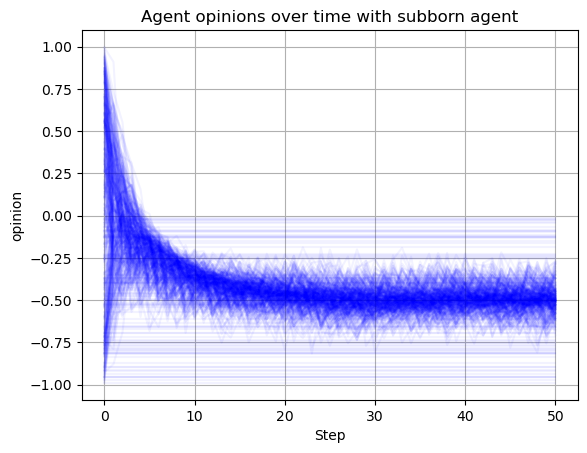

In [8]:
model = OpinionWorld(initialisation_type='stubborn', seed=42)

# 50 steps of model
for i in range(50):
    model.step()

# collect data
model_df = model.datacollector.get_agent_vars_dataframe().reset_index()

# plot
g = sns.lineplot(data=model_df, x='Step', y='opinion', units='AgentID', color = 'blue', alpha=0.05, estimator=None)
plt.title('Agent opinions over time with subborn agent')
plt.grid()

In [ ]:
params = {
        'initialisation_type': 'stubborn',
        'stubborn_proportion': np.linspace(0.05, 0.2, 10),
        'seed': rng.integers(1, 100, 15)
        }

results = batch_run(
        OpinionWorld,
        parameters=params,
        max_steps=100,
        )

results_df = pd.DataFrame(results)


  0%|          | 0/150 [00:00<?, ?it/s]

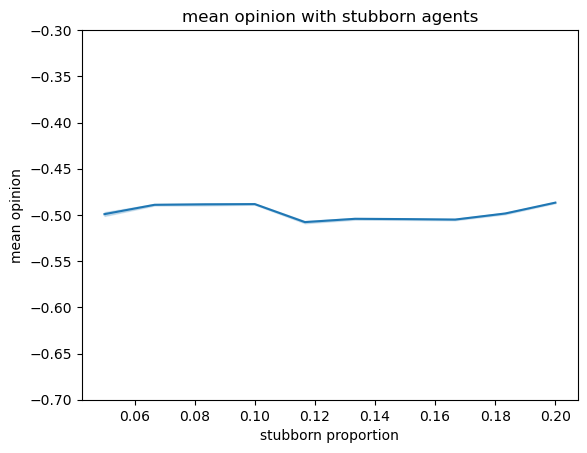

In [ ]:
final_df = results_df.loc[(results_df['Step']==results_df['Step'].max())]

sns.lineplot(data=final_df, x='stubborn_proportion', y='opinions_mean')
plt.ylim(-0.7, -0.3)
plt.xlabel('stubborn proportion')
plt.ylabel('mean opinion')
plt.title('mean opinion with stubborn agents')
plt.show()

The graph shows that after simulating the presence of stubborn agents, the model converges to a negative opinion of -0.5, regardless of the proportion. This is because, provided the confidence level is high enough to converge to one clique (in this senario, confidence level = 2 (default)), the stubborn agents will always bring agents closer to their opinion, who in turn will bring other agents closer to the same opinion.

As a result, the final consensus lies around the average of the stubborn agents opinions: -0.5 (stubborn agents are uniformly distributed between -1 and 0). Therefore the hypothesis that stubborn agents who refuse to change their opinion cause a negative final consensus can be accepted.

In [5]:
# Tests

model = OpinionWorld(initialisation_type='stubborn', stubborn_proportion=0.3, seed=42)

# record initial opinions of stubborn agents
initial_stubborn_opinions = {agent.unique_id: agent.opinion for agent in model.agents if agent.stubborn}

for i in range(100):
    model.step()

# check stubborn agents haven't changed
for agent in model.agents:
    if agent.stubborn:
        assert agent.opinion == initial_stubborn_opinions[agent.unique_id]

# check proportion is correct
actual_prop = sum(1 for agent in model.agents if agent.stubborn) / model.num_agents
print(f'actual stubborn proportion {actual_prop:.4f}')


actual stubborn proportion 0.2880


These tests show that stubborn agent opinions do not change and the proportion of stubborn agents is as expected.

The initial one run graph also supports this with the straight horizontal lines showing that some agent opinions are not changing.